# Grover's Search Algorithm — a hands-on Qiskit notebook

### Faculty Development Programme in Quantum Computing · IIT Roorkee

---

**What this notebook is for.** By the end you will be able to *build Grover's algorithm from its parts*, *see why it works geometrically*, and *predict its behaviour* — including where it goes wrong. Everything runs in Google Colab with **Qiskit 2.5.0 / Aer 0.17.2**.

**The one idea to hold onto.** Grover's speed-up is **not** parallel evaluation of the function. A quantum computer does *not* "try all inputs at once and read off the answer." What actually happens is that **indistinguishable computational paths interfere**: the oracle plants a relative phase on the solution, and the diffuser turns that phase difference into a difference in *amplitude*. Probability is the squared magnitude of an amplitude, so a tiny, repeatedly-amplified amplitude becomes an almost-certain measurement. Keep this thesis in view: *indistinguishable alternatives interfere; probabilities are squared magnitudes of amplitudes.*

**Roadmap**

1. The search problem, and why interference (not parallelism)
2. The toolkit: uniform state, **oracle**, **diffuser** — built by hand
3. Amplitude-level walkthrough: *inversion about the mean*
4. **Geometric intuition**: two reflections = one rotation
5. How many iterations? The $\lfloor\frac{\pi}{4}\sqrt{N/M}\rfloor$ rule
6. Worked cases — A) $n=2$ exact, B) $n=3$, C) many solutions, D) **over-rotation**, E) the $\sqrt N$ speed-up
7. An interactive explorer to play with
8. Graded exercises (★–★★★★) with hints

> **Endianness convention (kept consistent with the rest of the course).** All bit-strings are written **MSB-first**, so string position $k$ corresponds to qubit $n\!-\!1\!-\!k$. Qiskit prints measurement outcomes the same way, so a state we *mark* as `"101"` is *measured* as `"101"`, character-for-character.

## 0 · Setup

The cell below installs the course stack **only if it is missing** (so it is a no-op on a machine that already has Qiskit), imports everything, fixes the random seed to `42` for reproducibility, and sets a consistent plot style.

In [1]:
# --- Colab-safe setup -------------------------------------------------------
try:
    import qiskit  # already present? then skip the install
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "qiskit==2.5.0", "qiskit-aer==0.17.2", "pylatexenc", "ipywidgets"],
                   check=True)
    import qiskit

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

np.random.seed(42)                       # reproducibility across the whole course
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.titleweight": "bold", "axes.axisbelow": True,
})
# a small, consistent colour language used throughout
C_MARK   = "#c1272d"   # the marked / "winner" states
C_UNMARK = "#2b6cb0"   # everything else
C_MEAN   = "#111111"   # the mean line in "inversion about the mean"
C_GOOD   = "#2ca02c"

print("Qiskit", qiskit.__version__, "| Aer", __import__('qiskit_aer').__version__)

Qiskit 2.5.0 | Aer 0.17.2


## 1 · The search problem, and why *interference*

We are given a function $f:\{0,1\}^n \to \{0,1\}$ as a black box ("oracle"). Exactly $M$ of the $N = 2^n$ inputs are **solutions**: $f(x)=1$. We want to find one.

*Classically*, with a structureless black box you have no better strategy than trying inputs one by one: on average $\sim N/(2M)$ queries, i.e. $O(N)$. Grover finds a solution with high probability in only $O(\sqrt{N/M})$ queries — a **quadratic** speed-up.

**Why this is not "parallelism."** It is true that one Hadamard layer places the register in a uniform superposition $\lvert s\rangle=\frac1{\sqrt N}\sum_x\lvert x\rangle$, and that one oracle call touches every branch. But if you *measured* right there, you would get a uniformly random $x$ — no advantage at all. The uniform superposition **by itself carries no computational information**. The advantage comes entirely from what we do *between* preparing the superposition and measuring: the oracle writes a *phase*, and the diffuser makes the phased branch **interfere constructively** while the others interfere destructively. Amplitude, not a lucky parallel read-out, is what we amplify.

We now build the two operators that do this.

## 2 · The toolkit — oracle and diffuser, by hand

We deliberately **do not** call Qiskit's high-level `Grover` class. Building the pieces ourselves keeps the physics transparent.

**The phase oracle** flips the sign of the amplitude of each solution and leaves the rest alone:
$$U_f\,\lvert x\rangle=(-1)^{f(x)}\lvert x\rangle,\qquad\text{i.e.}\qquad U_f=I-2\!\!\sum_{x:\,f(x)=1}\!\!\lvert x\rangle\langle x\rvert .$$
To mark a particular bit-string we surround a multi-controlled-$Z$ (which imprints $-1$ on $\lvert 1\cdots1\rangle$) with $X$ gates on the qubits that should be $0$.

**The diffuser** (Grover diffusion operator) is the reflection about the uniform state:
$$D = 2\lvert s\rangle\langle s\rvert-I = H^{\otimes n}\,(2\lvert 0\rangle\langle 0\rvert-I)\,H^{\otimes n}.$$
Circuit-wise: $H^{\otimes n}$, then $X^{\otimes n}$, a multi-controlled-$Z$, $X^{\otimes n}$, $H^{\otimes n}$. That standard circuit actually realises $-(2\lvert s\rangle\langle s\rvert-I)$; we add a global phase of $\pi$ so it equals **exactly** $2\lvert s\rangle\langle s\rvert-I$. The correction is physically invisible to measurements, but it keeps the geometry (next section) perfectly clean — the state vector rotates *monotonically* with real, positive coordinates.

In [2]:
def _mcz(qc, n):
    """Phase flip on |11...1>: multi-controlled Z acting on all n qubits."""
    if n == 1:
        qc.z(0)
    else:
        qc.h(n - 1)
        qc.mcx(list(range(n - 1)), n - 1)   # C^{n-1}X  ==  C^{n-1}Z conjugated by H
        qc.h(n - 1)

def _flips_for(n, bitstring):
    """Qubits that are '0' in an MSB-first bit-string (they need an X to act as a control)."""
    return [n - 1 - k for k, ch in enumerate(bitstring) if ch == '0']

def phase_oracle(n, marked):
    """U_f = I - 2 sum_{w in marked} |w><w|.  `marked` = list of MSB-first bit-strings."""
    qc = QuantumCircuit(n, name="Oracle")
    for w in marked:
        f = _flips_for(n, w)
        if f: qc.x(f)
        _mcz(qc, n)
        if f: qc.x(f)
    return qc

def diffuser(n):
    """Exact reflection about the uniform state:  D = 2|s><s| - I."""
    qc = QuantumCircuit(n, name="Diffuser")
    qc.global_phase = np.pi          # turns -(2|s><s|-I) into +(2|s><s|-I)
    qc.h(range(n)); qc.x(range(n))
    _mcz(qc, n)
    qc.x(range(n)); qc.h(range(n))
    return qc

def grover_circuit(n, marked, iters, measure=False):
    """H^n, then `iters` copies of (oracle, diffuser)."""
    qc = QuantumCircuit(n, name=f"Grover(k={iters})")
    qc.h(range(n))                                   # uniform superposition |s>
    orc, dif = phase_oracle(n, marked), diffuser(n)
    for _ in range(iters):
        qc.compose(orc, inplace=True)
        qc.compose(dif, inplace=True)
    if measure:
        qc.measure_all()
    return qc

print("Toolkit ready: phase_oracle · diffuser · grover_circuit")

Toolkit ready: phase_oracle · diffuser · grover_circuit


A couple of convenience helpers we will reuse: one to read the exact state vector, one to run a real (shot-based) simulation on Aer, and two small analytic formulas.

In [3]:
def statevector_of(qc):
    """Exact final state (no measurement)."""
    return Statevector.from_instruction(qc)

def run_counts(n, marked, iters, shots=4096):
    """Shot-based measurement on the Aer simulator."""
    qc = grover_circuit(n, marked, iters, measure=True)
    sim = AerSimulator()
    result = sim.run(transpile(qc, sim), shots=shots, seed_simulator=42).result()
    return result.get_counts()

def success_prob(n, marked, iters):
    """Exact probability of measuring ANY marked state."""
    p = statevector_of(grover_circuit(n, marked, iters)).probabilities_dict()
    return sum(p.get(w, 0.0) for w in marked)

def theta_of(N, M):
    """Rotation angle per Grover iteration:  theta = 2 arcsin(sqrt(M/N))."""
    return 2 * np.arcsin(np.sqrt(M / N))

def optimal_iters(N, M):
    """Nearest-integer optimum:  round( (pi/2)/theta - 1/2 )."""
    return max(round((np.pi / 2) / theta_of(N, M) - 0.5), 0)

print("Helpers ready.")

Helpers ready.


## 3 · Amplitude-level walkthrough: *inversion about the mean*

Before any geometry, let us just **watch the amplitudes** for a single Grover iteration on $n=3$ with the solution `"101"`.

Read the three panels left to right:

1. **Uniform** — every amplitude is $1/\sqrt N$; the dashed line is their mean.
2. **After the oracle** — only the solution's amplitude has flipped sign. Its magnitude is unchanged, so a measurement *now* would still be uniform. Nothing has been gained yet — but a *phase* has been planted.
3. **After the diffuser** — each amplitude is reflected through the mean ($a\mapsto 2\bar a-a$). Because the solution sits far *below* the mean (it went negative), it is thrown far *above* it; the others, sitting just above the mean, are nudged down. The solution's probability has jumped. **That reflection through the mean is the interference.**

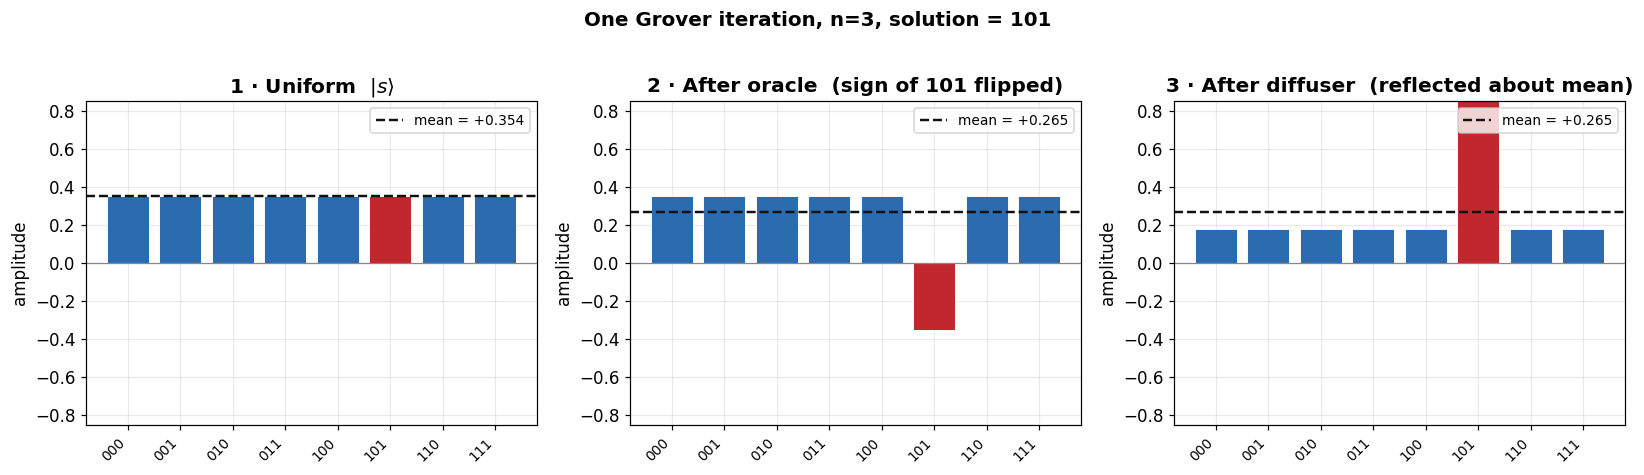

P(101) : uniform=0.125  ->  after 1 iteration=0.781


In [4]:
def amp_panel(ax, amps, marked_idx, title):
    amps = np.real(amps)
    N = len(amps)
    colors = [C_MARK if i in marked_idx else C_UNMARK for i in range(N)]
    ax.bar(range(N), amps, color=colors, edgecolor="white", linewidth=0.6)
    mean = amps.mean()
    ax.axhline(mean, ls="--", lw=1.6, color=C_MEAN, label=f"mean = {mean:+.3f}")
    ax.axhline(0, lw=0.8, color="#888")
    ax.set_xticks(range(N))
    ax.set_xticklabels([format(i, f"0{int(np.log2(N))}b") for i in range(N)],
                       rotation=45, ha="right", fontsize=9)
    ax.set_ylim(-0.85, 0.85)
    ax.set_title(title); ax.set_ylabel("amplitude")
    ax.legend(loc="upper right", fontsize=9)

n, marked = 3, ["101"]
m_idx = [int(w, 2) for w in marked]

# state after each stage of ONE iteration
sv_unif   = statevector_of(grover_circuit(n, marked, 0)).data
qc_orc = grover_circuit(n, marked, 0); qc_orc.compose(phase_oracle(n, marked), inplace=True)
sv_orc    = statevector_of(qc_orc).data
sv_after  = statevector_of(grover_circuit(n, marked, 1)).data

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
amp_panel(axes[0], sv_unif,  m_idx, "1 · Uniform  $|s\\rangle$")
amp_panel(axes[1], sv_orc,   m_idx, "2 · After oracle  (sign of 101 flipped)")
amp_panel(axes[2], sv_after, m_idx, "3 · After diffuser  (reflected about mean)")
fig.suptitle("One Grover iteration, n=3, solution = 101", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"P(101) : uniform={abs(sv_unif[m_idx[0]])**2:.3f}  ->  "
      f"after 1 iteration={abs(sv_after[m_idx[0]])**2:.3f}")

## 4 · Geometric intuition: two reflections make one rotation

Here is the picture that makes Grover *obvious*. Although the register lives in an $N$-dimensional space, the whole algorithm stays inside a **2-dimensional plane**. Define two orthonormal directions:

$$\lvert w\rangle=\frac1{\sqrt M}\!\!\sum_{x:\,f(x)=1}\!\!\lvert x\rangle\quad(\text{solutions}),\qquad
\lvert s'\rangle=\frac1{\sqrt{N-M}}\!\!\sum_{x:\,f(x)=0}\!\!\lvert x\rangle\quad(\text{non-solutions}).$$

The uniform state lives in their span, tilted only slightly toward the solutions:
$$\lvert s\rangle=\sin\tfrac{\theta}{2}\,\lvert w\rangle+\cos\tfrac{\theta}{2}\,\lvert s'\rangle,\qquad \sin\tfrac{\theta}{2}=\sqrt{\tfrac{M}{N}}.$$

Now watch what the two operators do **as reflections in this plane**:

* **Oracle** $=$ reflection across the $\lvert s'\rangle$ axis (it flips the sign of the $\lvert w\rangle$-component).
* **Diffuser** $=$ reflection across the $\lvert s\rangle$ line.

A reflection followed by a reflection is a **rotation** — by twice the angle between the two mirrors. The mirrors are $\theta/2$ apart, so **one Grover iteration rotates the state by $\theta$ toward $\lvert w\rangle$.** After $k$ iterations,

$$\lvert\psi_k\rangle=\sin\!\Big(\tfrac{2k+1}{2}\theta\Big)\lvert w\rangle+\cos\!\Big(\tfrac{2k+1}{2}\theta\Big)\lvert s'\rangle,\qquad
P_{\text{success}}(k)=\sin^2\!\Big(\tfrac{2k+1}{2}\theta\Big).$$

The diagram below draws the single-iteration mechanics explicitly: start, reflect down across $\lvert s'\rangle$ (oracle), reflect across $\lvert s\rangle$ (diffuser), and land rotated by $\theta$.

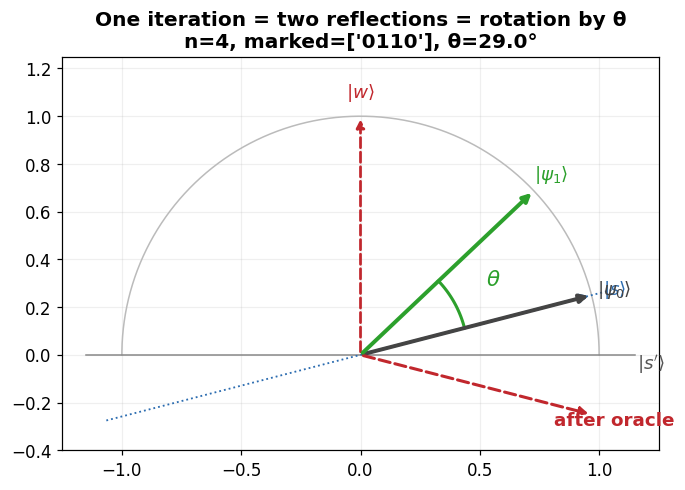

In [5]:
def plane_coords(sv, n, marked):
    """Project a state onto (|s'>, |w>) and return (x, y) real coordinates."""
    d = np.asarray(sv.data); N = 2 ** n; M = len(marked)
    idx = [int(w, 2) for w in marked]
    y = np.real(d[idx].sum() / np.sqrt(M))                    # <w|psi>
    mask = np.ones(N, bool); mask[idx] = False
    x = np.real(d[mask].sum() / np.sqrt(N - M))               # <s'|psi>
    return x, y

def _arrow(ax, x, y, color, label=None, lw=2.6, ls="-"):
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, ls=ls))
    if label:
        ax.text(x * 1.10, y * 1.10, label, color=color, fontsize=12, fontweight="bold",
                ha="center", va="center")

def draw_two_reflections(n, marked, k=0):
    th = theta_of(2 ** n, len(marked)); a = (2 * k + 1) * th / 2   # start angle
    fig, ax = plt.subplots(figsize=(6.4, 6.4))
    t = np.linspace(0, np.pi, 200)
    ax.plot(np.cos(t), np.sin(t), color="#bbb", lw=1)             # unit half-circle
    ax.plot([-1.15, 1.15], [0, 0], color="#888", lw=1)           # |s'> axis
    # |s> mirror line
    ax.plot([-1.1*np.cos(th/2), 1.1*np.cos(th/2)],
            [-1.1*np.sin(th/2), 1.1*np.sin(th/2)], color=C_UNMARK, lw=1.2, ls=":")
    _arrow(ax, np.cos(th/2), np.sin(th/2), C_UNMARK, r"$|s\rangle$", lw=1.8, ls="--")
    _arrow(ax, 0, 1, C_MARK, r"$|w\rangle$", lw=1.8, ls="--")
    ax.text(1.16, -0.06, r"$|s'\rangle$", fontsize=12, fontweight="bold", color="#555")
    # start, after oracle (reflect across x), after diffuser (reflect across |s>)
    _arrow(ax, np.cos(a), np.sin(a), "#444", rf"$|\psi_{k}\rangle$")
    _arrow(ax, np.cos(-a), np.sin(-a), C_MARK, "after oracle", lw=2.0, ls="--")
    af = th + a
    _arrow(ax, np.cos(af), np.sin(af), C_GOOD, rf"$|\psi_{k+1}\rangle$")
    # rotation wedge
    w = np.linspace(a, af, 40)
    ax.plot(0.45*np.cos(w), 0.45*np.sin(w), color=C_GOOD, lw=2)
    ax.text(0.6*np.cos((a+af)/2), 0.6*np.sin((a+af)/2), r"$\theta$",
            color=C_GOOD, fontsize=14, fontweight="bold")
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-0.4, 1.25); ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.set_title(f"One iteration = two reflections = rotation by θ\n"
                 f"n={n}, marked={marked}, θ={np.degrees(th):.1f}°")
    plt.tight_layout(); plt.show()

draw_two_reflections(4, ["0110"], k=0)

And here is the *cumulative* effect: the state vector marching from $\lvert s\rangle$ (barely tilted off $\lvert s'\rangle$) up toward $\lvert w\rangle$, one $\theta$-step per iteration. We overlay the **numerically extracted** coordinates on top of the analytic angles — they agree exactly, which is the payoff of the clean-geometry phase correction we made in the diffuser.

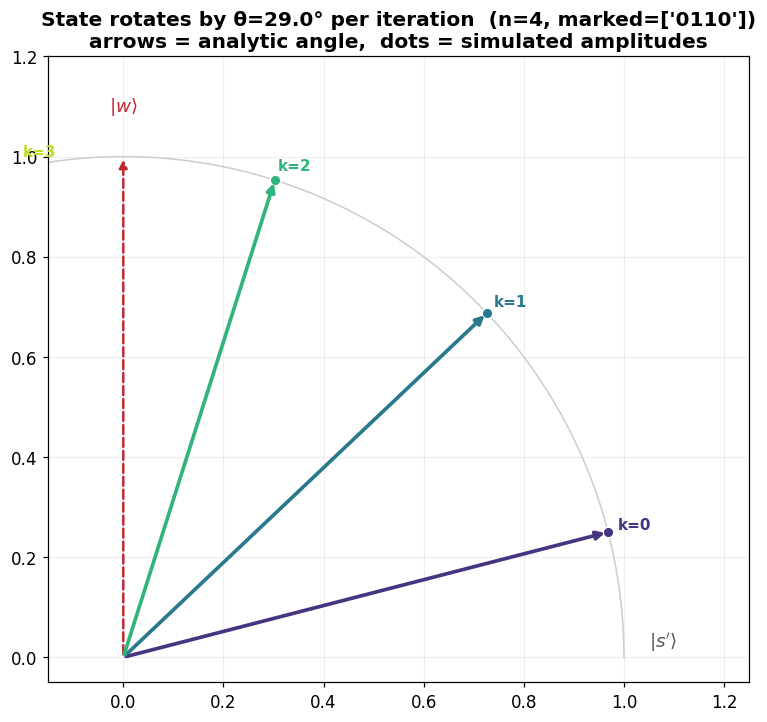

In [6]:
def draw_rotation_frames(n, marked, kmax=None):
    N, M = 2 ** n, len(marked); th = theta_of(N, M)
    if kmax is None: kmax = optimal_iters(N, M)
    fig, ax = plt.subplots(figsize=(7.2, 6.6))
    t = np.linspace(0, np.pi/2 + 0.15, 200)
    ax.plot(np.cos(t), np.sin(t), color="#ccc", lw=1)
    _arrow(ax, 0, 1, C_MARK, r"$|w\rangle$", lw=1.6, ls="--")
    ax.text(1.05, 0.02, r"$|s'\rangle$", fontsize=12, fontweight="bold", color="#555")
    cmap = plt.cm.viridis(np.linspace(0.15, 0.9, kmax + 1))
    for k in range(kmax + 1):
        a = (2 * k + 1) * th / 2
        ax.annotate("", xy=(np.cos(a), np.sin(a)), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=cmap[k], lw=2.4))
        # numerically-extracted coordinate as a dot
        x, y = plane_coords(statevector_of(grover_circuit(n, marked, k)), n, marked)
        ax.plot(x, y, "o", color=cmap[k], ms=7, mec="white")
        ax.text(1.02*np.cos(a), 1.02*np.sin(a), f"k={k}", color=cmap[k],
                fontsize=10, fontweight="bold")
    ax.set_xlim(-0.15, 1.25); ax.set_ylim(-0.05, 1.2); ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.set_title(f"State rotates by θ={np.degrees(th):.1f}° per iteration  "
                 f"(n={n}, marked={marked})\narrows = analytic angle,  dots = simulated amplitudes")
    plt.tight_layout(); plt.show()

draw_rotation_frames(4, ["0110"])

## 5 · How many iterations? The $\lfloor\frac{\pi}{4}\sqrt{N/M}\rfloor$ rule

We want to stop when the state points as close to $\lvert w\rangle$ as possible, i.e. when the angle $\frac{2k+1}{2}\theta\approx\frac{\pi}{2}$. Solving for $k$:

$$k^\star=\Big\lfloor\frac{\pi/2}{\theta}-\frac12\Big\rceil\;\approx\;\frac{\pi}{4}\sqrt{\frac{N}{M}}\quad(\text{for }M\ll N).$$

That $\sqrt N$ is the whole point — quadratically fewer queries than the classical $O(N)$. The success probability is the sinusoid $\sin^2\!\big(\frac{2k+1}{2}\theta\big)$; below we plot it, mark $k^\star$, and confirm the exact simulation lands on the analytic curve.

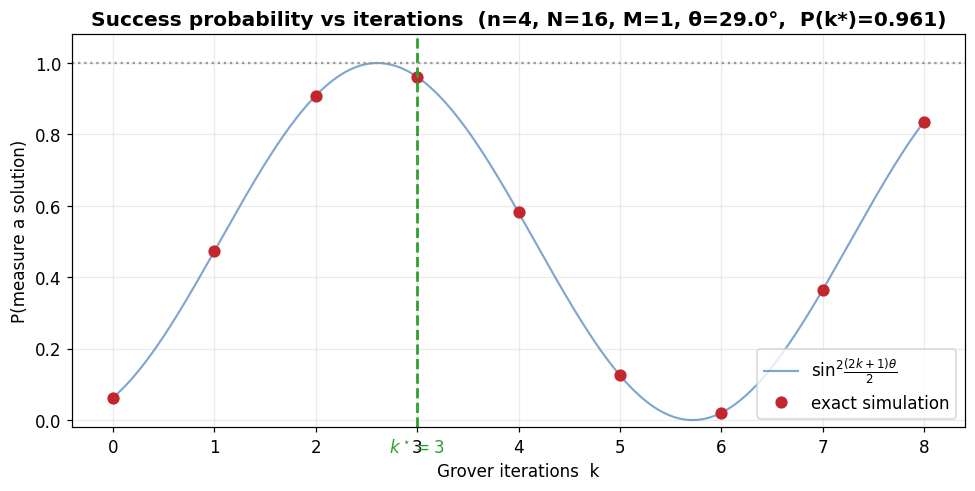

In [7]:
def plot_prob_vs_iters(n, marked, kmax=None):
    N, M = 2 ** n, len(marked); th = theta_of(N, M); kstar = optimal_iters(N, M)
    if kmax is None: kmax = max(2 * kstar + 2, 6)
    ks = np.arange(0, kmax + 1)
    analytic = np.sin((2 * ks + 1) * th / 2) ** 2
    simulated = [success_prob(n, marked, int(k)) for k in ks]
    fig, ax = plt.subplots(figsize=(9, 4.6))
    kk = np.linspace(0, kmax, 400)
    ax.plot(kk, np.sin((2 * kk + 1) * th / 2) ** 2, color=C_UNMARK, lw=1.4, alpha=0.6,
            label=r"$\sin^2\!\frac{(2k+1)\theta}{2}$")
    ax.plot(ks, simulated, "o", color=C_MARK, ms=7, label="exact simulation")
    ax.axvline(kstar, ls="--", color=C_GOOD, lw=1.8)
    ax.axhline(1.0, ls=":", color="#999")
    ax.text(kstar, -0.09, f"$k^\\star={kstar}$", color=C_GOOD, ha="center", fontweight="bold")
    ax.set_xlabel("Grover iterations  k"); ax.set_ylabel("P(measure a solution)")
    ax.set_ylim(-0.02, 1.08); ax.legend(loc="lower right")
    ax.set_title(f"Success probability vs iterations  (n={n}, N={N}, M={M}, "
                 f"θ={np.degrees(th):.1f}°,  P(k*)={simulated[kstar]:.3f})")
    plt.tight_layout(); plt.show()

plot_prob_vs_iters(4, ["0110"])

## 6 · Worked cases

We now sweep through the situations you will want to demonstrate live.

### Case A — $n=2$, one solution: Grover is *exact*

With $N=4,\,M=1$ we have $\sin\frac\theta2=\frac12$, so $\theta=60°$ and $\frac{2k+1}{2}\theta$ hits exactly $90°$ at $k=1$. **A single iteration gives the solution with certainty** — no over/undershoot. This is the cleanest possible demonstration.

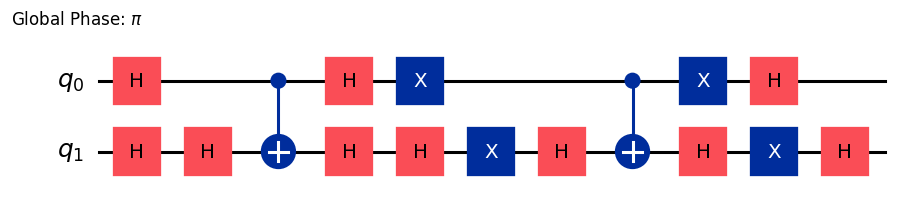

Exact P(11) after 1 iteration: 1.0


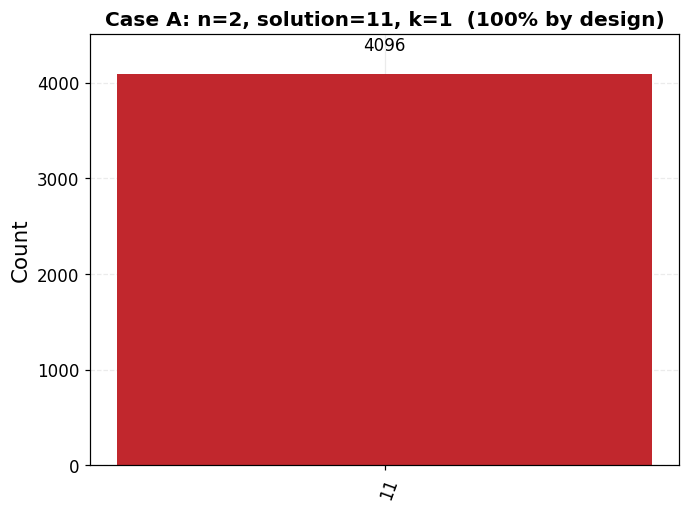

In [8]:
n, marked = 2, ["11"]
qc = grover_circuit(n, marked, 1)
display(qc.draw("mpl", fold=-1))
print("Exact P(11) after 1 iteration:", round(success_prob(n, marked, 1), 6))

counts = run_counts(n, marked, 1, shots=4096)
fig = plot_histogram(counts, color=[C_MARK if k in marked else C_UNMARK for k in sorted(counts)],
                     title="Case A: n=2, solution=11, k=1  (100% by design)")
display(fig); plt.close(fig)

### Case B — $n=3$, one solution: two iterations

Now $N=8$, so $\theta\approx41.4°$ and $k^\star=2$. One iteration is not enough; two lands us at $P\approx0.945$. Watch the geometry rotate past the halfway point and the histogram concentrate on the solution.

k* = 2  | P(k*) = 0.9453


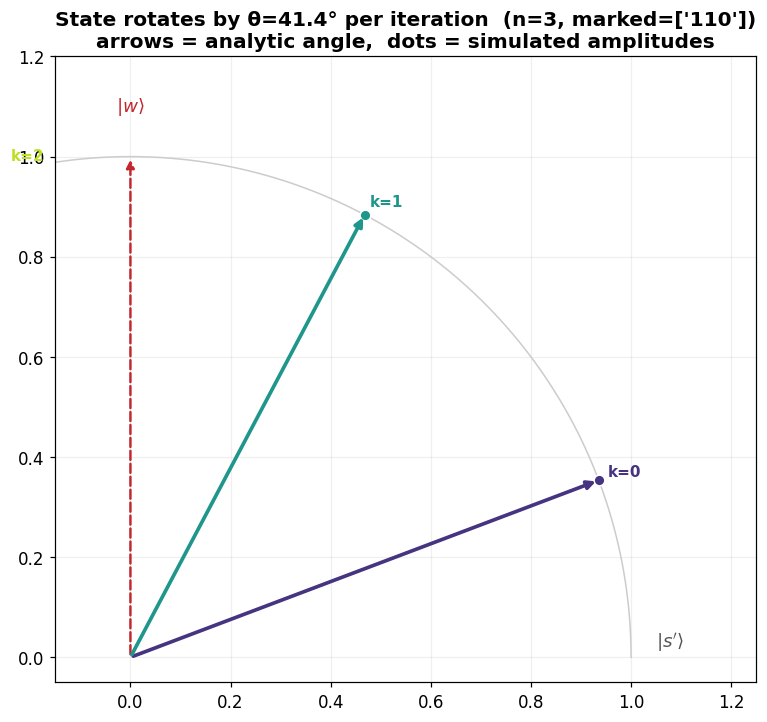

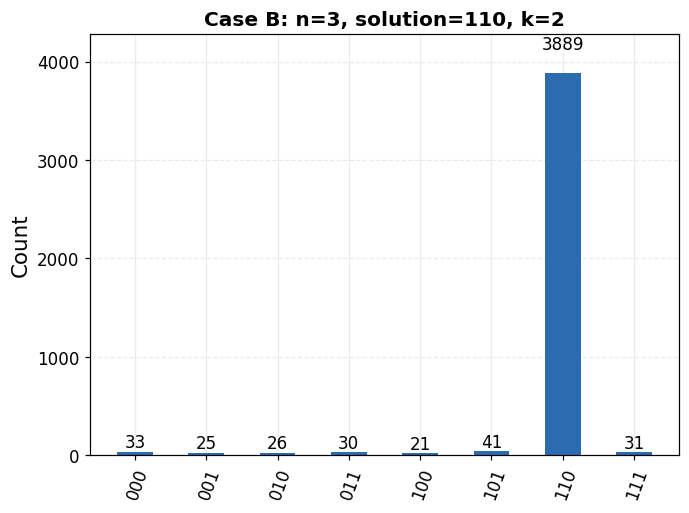

In [9]:
n, marked = 3, ["110"]
print("k* =", optimal_iters(8, 1), " | P(k*) =", round(success_prob(n, marked, 2), 4))
draw_rotation_frames(n, marked)
counts = run_counts(n, marked, 2, shots=4096)
fig = plot_histogram(counts, color=[C_MARK if k in marked else C_UNMARK for k in sorted(counts)],
                     title="Case B: n=3, solution=110, k=2")
display(fig); plt.close(fig)

### Case C — several solutions at once

If there are $M$ solutions, the starting tilt is larger ($\sin\frac\theta2=\sqrt{M/N}$), so **each step rotates faster and you need fewer of them**. With $n=4$ and $M=4$ solutions, $k^\star$ drops to $1$. The flip side: with many solutions you can reach the optimum in very few steps, but the *window* to stop is narrower.

N=16, M=4, theta=60.0 deg, k* = 1, P(k*) = 1.0000


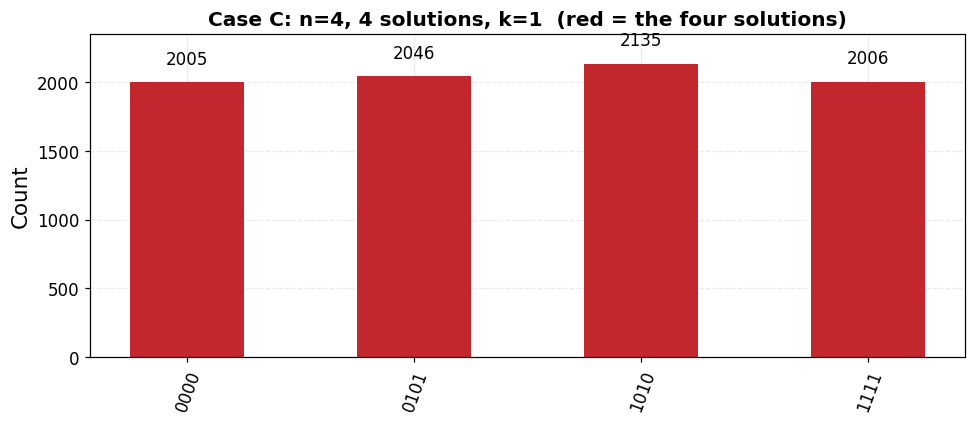

In [10]:
n = 4
marked = ["0000", "0101", "1010", "1111"]        # M = 4 solutions
N, M = 2 ** n, len(marked)
print(f"N={N}, M={M}, theta={np.degrees(theta_of(N,M)):.1f} deg, k* = {optimal_iters(N,M)}, "
      f"P(k*) = {success_prob(n, marked, optimal_iters(N,M)):.4f}")

counts = run_counts(n, marked, optimal_iters(N, M), shots=8192)
order = sorted(counts)
fig = plot_histogram(counts, color=[C_MARK if k in marked else C_UNMARK for k in order],
                     title=f"Case C: n=4, {M} solutions, k={optimal_iters(N,M)}  "
                           f"(red = the four solutions)", figsize=(9,4))
for lab in fig.axes[0].get_xticklabels(): lab.set_rotation(70)
fig.tight_layout(); display(fig); plt.close(fig)

### Case D — Over-rotation

Grover is a rotation, and rotations don't stop on their own. If you keep applying iterations past $k^\star$, the state swings **past** $\lvert w\rangle$ and the success probability **falls again** — then rises, then falls, periodically. Souphlé: take it out at the right moment or it collapses. This is why "more iterations" is *not* "more better," and why knowing $M$ (to compute $k^\star$) matters.

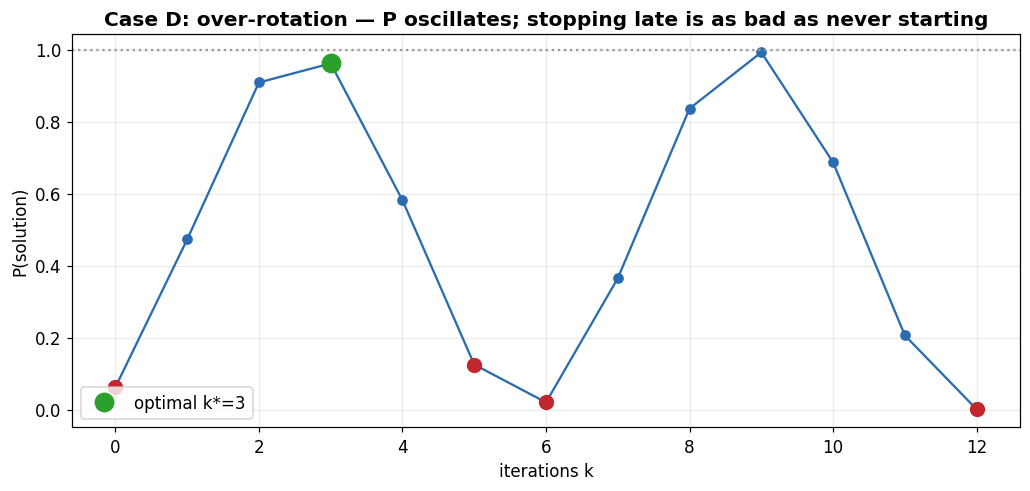

P by iteration: [np.float64(0.062), np.float64(0.473), np.float64(0.908), np.float64(0.961), np.float64(0.582), np.float64(0.125), np.float64(0.02), np.float64(0.365), np.float64(0.836), np.float64(0.992), np.float64(0.687), np.float64(0.206), np.float64(0.001)]
Peak at k*=3 (P=0.961); by k=6 it has collapsed to P=0.020


In [11]:
n, marked = 4, ["1001"]
N = 2 ** n; kstar = optimal_iters(N, 1)
ks = np.arange(0, 13)
ps = [success_prob(n, marked, int(k)) for k in ks]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(ks, ps, "-o", color=C_UNMARK, ms=6)
ax.plot(kstar, ps[kstar], "o", color=C_GOOD, ms=12, label=f"optimal k*={kstar}")
for k in ks:
    if ps[k] < 0.15:
        ax.plot(k, ps[k], "o", color=C_MARK, ms=9)
ax.axhline(1, ls=":", color="#999")
ax.set_xlabel("iterations k"); ax.set_ylabel("P(solution)")
ax.set_title("Case D: over-rotation — P oscillates; stopping late is as bad as never starting")
ax.legend(); plt.tight_layout(); plt.show()
print("P by iteration:", [round(p, 3) for p in ps])
print(f"Peak at k*={kstar} (P={ps[kstar]:.3f}); by k={kstar+3} it has collapsed to P={ps[kstar+3]:.3f}")

### Case E — the $\sqrt{N}$ speed-up, made concrete

Finally, the reason anyone cares. For a single solution, Grover needs $\approx\frac{\pi}{4}\sqrt N$ oracle calls, versus $\approx N/2$ for classical random search. The gap widens quadratically. Below, the required queries are plotted against $n$ (log scale) — and we validate a couple of points by actually simulating them.

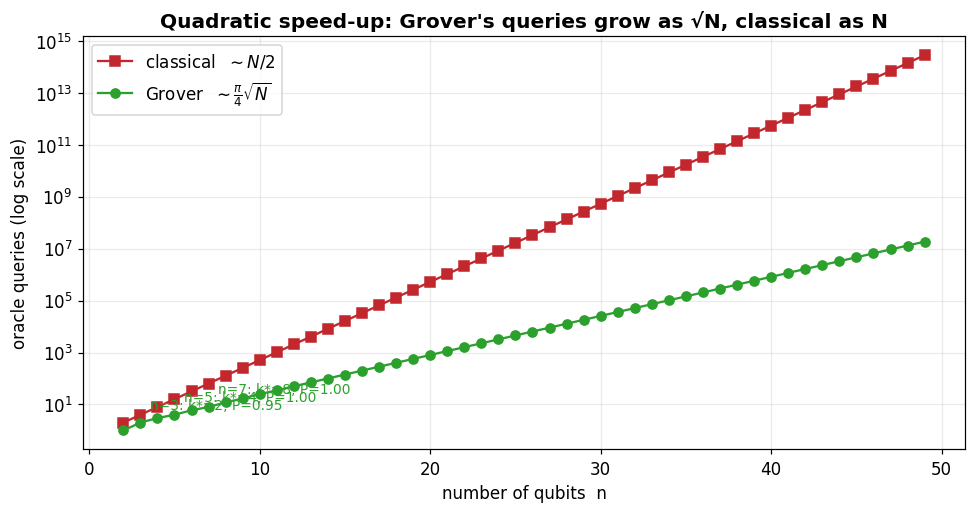

In [18]:
ns = np.arange(2, 50)
Ns = 2.0 ** ns
grover_q   = np.floor(np.pi / 4 * np.sqrt(Ns))    # ~ oracle calls Grover needs
classic_q  = Ns / 2                               # ~ average classical queries

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.semilogy(ns, classic_q, "-s", color=C_MARK, label=r"classical  $\sim N/2$")
ax.semilogy(ns, grover_q, "-o", color=C_GOOD, label=r"Grover  $\sim \frac{\pi}{4}\sqrt{N}$")
# validation dots: simulate small n and confirm high success at k*
for nn in [3, 5, 7]:
    kk = optimal_iters(2 ** nn, 1)
    w = format(0, f"0{nn}b")
    p = success_prob(nn, [w], kk)
    ax.annotate(f"n={nn}: k*={kk}, P={p:.2f}", (nn, np.pi/4*np.sqrt(2**nn)),
                textcoords="offset points", xytext=(6, 8), fontsize=9, color=C_GOOD)
ax.set_xlabel("number of qubits  n"); ax.set_ylabel("oracle queries (log scale)")
ax.set_title("Quadratic speed-up: Grover's queries grow as √N, classical as N")
ax.legend(); plt.tight_layout(); plt.show()

## 7 · Interactive explorer — play with it yourself

Move the sliders to choose the register size $n$, which single state is the solution, and how many iterations to run. The left panel shows the amplitudes (with the mean line); the right panel shows where the state sits in the $(\lvert s'\rangle,\lvert w\rangle)$ plane; the title reports the current and optimal iteration counts.

> The cell first renders one static example (so there is always a visible result), then attaches the sliders. If widgets are disabled in your environment, you still see the static figure and can call `explore(n=..., target=..., iters=...)` directly.

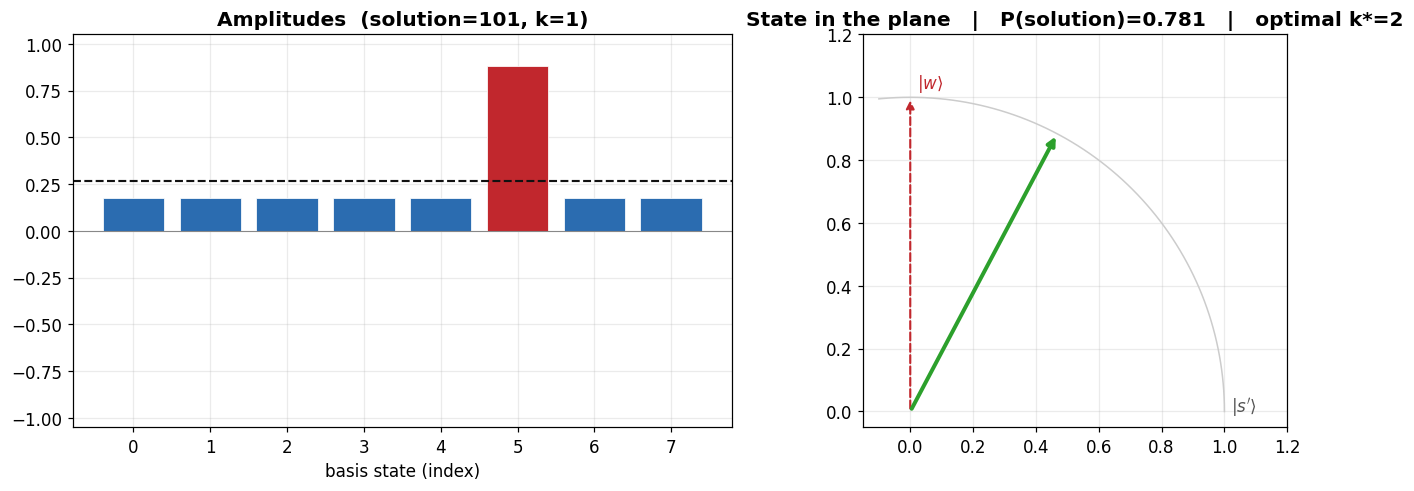

interactive(children=(IntSlider(value=3, description='n', max=5, min=2), IntSlider(value=5, description='solut…

In [13]:
def explore(n=3, target=5, iters=1):
    n = int(n); N = 2 ** n
    target = int(np.clip(target, 0, N - 1))
    iters = int(np.clip(iters, 0, 15))
    marked = [format(target, f"0{n}b")]
    sv = statevector_of(grover_circuit(n, marked, iters))
    kstar = optimal_iters(N, 1); P = success_prob(n, marked, iters)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
    # amplitudes
    amps = np.real(sv.data); colors = [C_MARK if i == target else C_UNMARK for i in range(N)]
    a1.bar(range(N), amps, color=colors, edgecolor="white", linewidth=0.5)
    a1.axhline(amps.mean(), ls="--", color=C_MEAN, lw=1.4)
    a1.axhline(0, lw=0.7, color="#888")
    a1.set_title(f"Amplitudes  (solution={marked[0]}, k={iters})")
    a1.set_ylim(-1.05, 1.05); a1.set_xlabel("basis state (index)")
    # geometry
    th = theta_of(N, 1)
    t = np.linspace(0, np.pi / 2 + 0.1, 150)
    a2.plot(np.cos(t), np.sin(t), color="#ccc", lw=1)
    a2.annotate("", xy=(0, 1), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=C_MARK, lw=1.4, ls="--"))
    x, y = plane_coords(sv, n, marked)
    a2.annotate("", xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=C_GOOD, lw=2.6))
    a2.text(0.02, 1.03, r"$|w\rangle$", color=C_MARK, fontweight="bold")
    a2.text(1.02, 0.0, r"$|s'\rangle$", color="#555", fontweight="bold")
    a2.set_xlim(-0.15, 1.2); a2.set_ylim(-0.05, 1.2); a2.set_aspect("equal")
    a2.set_title(f"State in the plane   |   P(solution)={P:.3f}   |   optimal k*={kstar}")
    plt.tight_layout(); plt.show()

# 1) always-visible static example
explore(n=3, target=5, iters=1)

# 2) attach interactive sliders (guarded so it degrades gracefully)
try:
    from ipywidgets import interact, IntSlider
    interact(explore,
             n=IntSlider(min=2, max=5, step=1, value=3, description="n"),
             target=IntSlider(min=0, max=31, step=1, value=5, description="solution idx"),
             iters=IntSlider(min=0, max=15, step=1, value=1, description="iterations"))
except Exception as e:
    print("Interactive widgets unavailable here; use explore(n=.., target=.., iters=..) instead.")

## 8 · Exercises

Difficulty ★ (warm-up) → ★★★★ (challenge). Each stub **returns an obviously wrong placeholder** so you can see at a glance whether you have finished it. Solutions are in the collapsible boxes — try first, peek later.

**Exercise 1 ★ — Predict, then check.** For $n=5$ with a single solution, compute $k^\star$ by hand from $\lfloor\frac{\pi}{4}\sqrt N\rfloor$, then verify with the toolkit and report $P(k^\star)$.

<details><summary>Solution outline</summary>

$N=32$, $\frac\pi4\sqrt{32}\approx4.44\Rightarrow k^\star=4$. `optimal_iters(32,1)` returns `4` and `success_prob(5,[w],4)≈0.999`.
</details>

In [14]:
def exercise1():
    n = 5
    kstar = -1            # <-- replace with your computation
    P = -1.0              # <-- replace
    # your code here
    return kstar, P

print("Exercise 1 (should NOT be (-1, -1.0)):", exercise1())

Exercise 1 (should NOT be (-1, -1.0)): (-1, -1.0)


**Exercise 2 ★★ — Build a two-solution oracle.** Use `phase_oracle` to mark **both** `"011"` and `"110"` on $n=3$, run to the optimal $k$, and plot the histogram. Confirm the two solutions together carry $>0.9$ probability.

<details><summary>Solution outline</summary>

`marked=["011","110"]`; `M=2`, `k*=optimal_iters(8,2)=1`; `run_counts(3,marked,1)`; summed solution probability ≈ `1.0`.
</details>

In [15]:
def exercise2():
    marked = []           # <-- put the two solutions here
    counts = {}           # <-- run and collect counts
    # your code here
    return marked, counts

print("Exercise 2:", exercise2())

Exercise 2: ([], {})


**Exercise 3 ★★★ — Find the over-rotation cliff.** For $n=4$, single solution, scan $k=0\ldots10$ and return the first $k$ at which the success probability drops **below** its value at $k^\star$. Relate it to the geometry (which angle has the state passed?).

<details><summary>Solution outline</summary>

Scan `success_prob`; the first $k>k^\star$ with $P(k)<P(k^\star)$ is $k^\star+1$. Geometrically the state has rotated past $90°$ (past $\lvert w\rangle$), so its $\lvert w\rangle$-component starts shrinking.
</details>

In [16]:
def exercise3():
    n = 4; kstar = optimal_iters(2**n, 1)
    first_drop = -1       # <-- replace
    # your code here
    return kstar, first_drop

print("Exercise 3:", exercise3())

Exercise 3: (3, -1)


**Exercise 4 ★★★★ — Amplitude amplification with a general starting state.** Instead of $H^{\otimes n}$, prepare $\lvert s\rangle$ with a *biased* rotation on each qubit (e.g. `ry(0.9, q)`), then apply oracle + a diffuser built about **that** state ($2\lvert s\rangle\langle s\rvert-I$ with $H^{\otimes n}\!\to$ your state-prep $A$: $D=A(2\lvert0\rangle\langle0\rvert-I)A^{\dagger}$). Show Grover still amplifies the solution, and discuss how the per-step angle changes when the starting overlap with $\lvert w\rangle$ changes.

<details><summary>Solution outline</summary>

Let $A$ be your state-prep. Oracle unchanged. Diffuser $=A\cdot(\text{X's, MCZ, X's})\cdot A^{\dagger}$ in the $\lvert 0\rangle$ frame — i.e. replace the outer $H^{\otimes n}$ layers of `diffuser` with $A$ and $A^{\dagger}$. The rotation angle becomes $\theta=2\arcsin|\langle w|s\rangle|$; a larger initial overlap means a bigger $\theta$ and fewer iterations. This is the general **amplitude amplification** primitive underneath Grover.
</details>

In [17]:
def exercise4():
    # Sketch: build A (state prep), oracle, and D = A (2|0><0|-I) A^dagger.
    # Return the success probability after your chosen k.
    P = -1.0              # <-- replace
    # your code here
    return P

print("Exercise 4:", exercise4())

Exercise 4: -1.0


## 9 · Summary and where this goes next

**The mechanism, in one breath.** Uniform superposition → oracle plants a phase on the solution → diffuser reflects every amplitude about the mean → the phased branch interferes constructively and grows. Repeat $\approx\frac{\pi}{4}\sqrt{N/M}$ times. It is **interference of amplitudes**, not parallel evaluation, and it is exactly a **rotation** in the two-dimensional $(\lvert s'\rangle,\lvert w\rangle)$ plane by $\theta=2\arcsin\sqrt{M/N}$ per step.

**Things to carry away**

* The uniform superposition alone tells you nothing — the work is done *between* preparation and measurement.
* Two reflections (oracle about $\lvert s'\rangle$, diffuser about $\lvert s\rangle$) compose into one rotation by $\theta$.
* Stop at $k^\star$: too few *or* too many iterations both cost you. Grover doesn't "converge," it *oscillates*.
* The speed-up is quadratic ($O(\sqrt N)$), not exponential — Grover is provably optimal for unstructured search.

**Natural next steps in the course**

* **Unknown $M$** → the BBHT randomised-schedule variant (you have the pieces already).
* **General amplitude amplification** (Exercise 4) → the workhorse behind many quantum subroutines.
* **Grover-as-rotation on the Bloch-style picture** connects straight back to the Stern–Gerlach $z\!\leftrightarrow\!x$ / Hadamard framing used earlier in the series.

*Now re-open the interactive explorer in §7 and break it on purpose — over-rotate it, crowd it with solutions, shrink it to $n=2$ — until the geometry feels inevitable.*